In [1]:
from pathlib import Path
import os
import subprocess
import sys
import getpass

def local_run():
    if os.path.exists("/content"):
        # running in Google Colab
        return False
    else:
        # running locally
        return True

def get_base_dir():
    if local_run():
        # running locally
        return Path(__vsc_ipynb_file__).resolve().parent.parent
    else:
        # running in Google Colab
        return Path("/content/deforestation-unet")


In [2]:

token = getpass.getpass("Enter your GitHub token: ")
base_dir = get_base_dir()
repo_url = f"https://{token}@github.com/barbara-barta/deforestation-unet.git"
if not base_dir.exists():
    print("Repository does not exist, cloning it now.")
    subprocess.run(["git", "clone", repo_url], check=True)
else:
    print("Repository already exists, pulling the latest changes.")
    subprocess.run(["git", "-C", str(base_dir), "pull"], check=True)

Repository already exists, pulling the latest changes.


In [22]:
%pip install -r {base_dir}/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [69]:
paths = {
    "RGB": base_dir / "data" / "RGB" /"raw",
    "AM4": base_dir / "data" / "AM4" / "raw",
    "AT4": base_dir / "data" / "AT4" / "raw",
}

downloads = {
    "RGB": ["https://doi.org/10.5281/zenodo.3233081", "Amazon Forest Dataset.rar"],
    "AM4": ["https://doi.org/10.5281/zenodo.4498086","AMAZON.rar"] }
    #"AT4": ["https://doi.org/10.5281/zenodo.4498086","ATLANTIC FOREST.rar"]}

for path in paths.values():
    path.mkdir(parents=True, exist_ok=True)

for dataset, [url, filename] in downloads.items():
    renamed_file =  paths[dataset] / filename.replace(" ", "")
    data_present = list(Path(paths[dataset]).glob("*.rar"))
    if not data_present:
        print(f"Downloading {dataset} data...")
        cmd = ["zenodo_get", "-o", str(paths[dataset]), "-g", filename] + [url]
        subprocess.run(cmd, check=True)
        print(f"Dataset {dataset} downloaded to {str(paths[dataset])}.")
    else:
        print(
            f"{dataset} data already exists at {str(paths[dataset])}, skipping download."
        )
    

    unziped_filename = filename.rsplit(".", 1)[0]
    unziped_data_present = any(p.is_dir() for p in paths[dataset].iterdir())

    if not unziped_data_present:
        print(f"Unzipping {dataset} data...")

        src = paths[dataset] / filename
        new_filename = filename.lower().replace(" ", "_")
        
        dst = paths[dataset] / new_filename
        if src.exists() and not dst.exists():
            src.rename(dst)
        
        unzipped_filepath =  paths[dataset] / new_filename.rsplit(".", 1)[0]

        print(str(dst))
        print(str(paths[dataset]))
        
        cmd = ["unrar", "x", "-o+", str(dst), str(paths[dataset])  ] 
        
        subprocess.run(cmd, check=True)
        print(f"Dataset {dataset} unzipped in {str(paths[dataset])}.")

RGB data already exists at C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\RGB\raw, skipping download.
Unzipping RGB data...
C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\RGB\raw\amazon_forest_dataset.rar
C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\RGB\raw


FileNotFoundError: [WinError 2] The system cannot find the file specified

In [72]:
rar_files = list(paths[dataset].glob("*.rar"))

if len(rar_files) == 0:
    print(f"Downloading {dataset} data...")
    subprocess.run(
        ["zenodo_get", "-o", str(paths[dataset]), "-g", filename, url],
        check=True
    )
    rar_files = list(paths[dataset].glob("*.rar"))



rar_path = rar_files[0]

# normalize name
normalized_name = rar_path.name.lower().replace(" ", "_")
normalized_path = paths[dataset] / normalized_name

if rar_path.name != normalized_name:
    rar_path.rename(normalized_path)
else:
    normalized_path = rar_path

# check if already unzipped (directory exists)
unzipped_present = any(p.is_dir() for p in paths[dataset].iterdir())

if not unzipped_present:
    print(f"Unzipping {dataset} data...")
    subprocess.run(
        ["unrar", "x", "-o+", str(normalized_path), str(paths[dataset])],
        check=True
    )


Unzipping RGB data...


FileNotFoundError: [WinError 2] The system cannot find the file specified

In [4]:
import sys, shutil
print(sys.platform)
print(shutil.which("unrar"))
print(list(paths["RGB"].iterdir()))


win32
None


NameError: name 'paths' is not defined

In [5]:
import shutil
print(shutil.which("unrar"))

None


## Exploring raster data

In [4]:
import rasterio as rio
import rasterio.plot as rplt
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
img = "Amazon_122.tiff_33.tiff"
img_path = base_dir / "data" / "DummyData" / img
src = rio.open(img_path)
src.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 512,
 'height': 512,
 'count': 3,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(9.016735026040612e-05, 0.0, -47.414771816388885,
        0.0, -8.990264377170196e-05, -4.399063756666667)}

In [6]:
#expressed in degrees as crs = WGS 84
print(f"Spatial resolution is {src.res} degrees.") 
print(f"Bounds of the area are {src.bounds} degrees.")

Spatial resolution is (9.016735026040612e-05, 8.990264377170196e-05) degrees.
Bounds of the area are BoundingBox(left=-47.414771816388885, bottom=-4.4450939102777784, right=-47.36860613305556, top=-4.399063756666667) degrees.


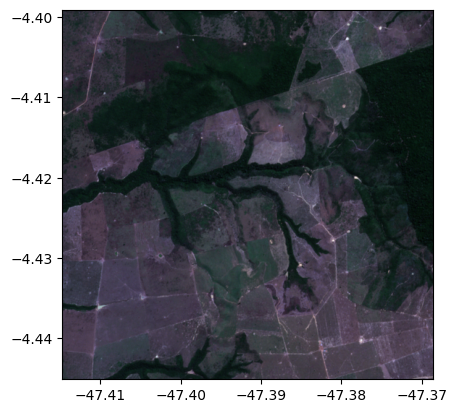

<Axes: >

In [7]:
rplt.show(src)

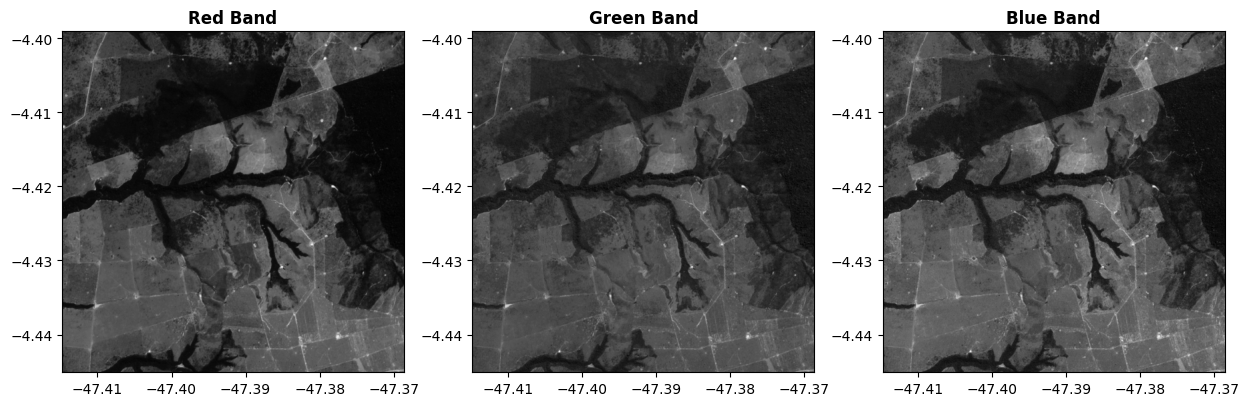

In [8]:
nr_bands = src.count
fig, axes = plt.subplots(1, nr_bands, figsize=(15, 15))
axes = axes.flatten()
titles = ["Red Band", "Green Band", "Blue Band"]
for i in range(axes.shape[0]):
    rplt.show((src, i+1), ax=axes[i], cmap='Greys_r', title = titles[i])

In [12]:
img = "AM4_1.tif"
src = rio.open(base_dir / "data" / "DummyData" / img)
src.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 512,
 'height': 512,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32620"]]'),
 'transform': Affine(10.0, 0.0, 746040.0,
        0.0, -10.0, 8712960.0)}

# Done in this session:
- 
# Next time:
- start EDA! locally!!
